# 🏠 Домашнее задание 3: Улучшение генерализации на mini-15 (Food-101)

**Цель:** Исследовать и улучшить обобщающую способность модели на подвыборке mini-15 из датасета Food-101 с помощью регуляризационных приёмов.

**План работы:**
1. **Baseline модель** - получение начальных метрик (Top-1, F1-macro, ECE)
2. **Улучшение №1** - добавление Dropout + Weight Decay
3. **Улучшение №2** - добавление Label Smoothing
4. **Сравнительный анализ** - сравнение всех метрик

---

## Подготовка окружения

Установим необходимые библиотеки и настроим окружение для работы.

In [1]:
# Импорты
import os, math, random, time
from dataclasses import dataclass
from typing import List, Tuple, Dict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from datasets import load_dataset
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode
from torchvision import models

# Для метрик
from sklearn.metrics import f1_score, confusion_matrix

# Функция для воспроизводимости
def set_seed(seed: int = 42) -> None:
    """Фиксирует ГСЧ для повторяемых результатов."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Определение устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Device: cuda


## Загрузка данных Food-101

Загрузим датасет Food-101 и создадим подвыборку mini-15 (15 классов).

In [2]:
# Загрузка датасета Food-101
DATA_CACHE_DIR = "./data"
ds = load_dataset("food101", cache_dir=DATA_CACHE_DIR)

print(f"Train: {len(ds['train'])} samples")
print(f"Validation: {len(ds['validation'])} samples")

# Создаем подвыборку mini-15 (15 классов)
SELECTED_CLASSES = [
    'apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare',
    'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito',
    'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake'
]

NUM_CLASSES = len(SELECTED_CLASSES)
print(f"Selected {NUM_CLASSES} classes: {SELECTED_CLASSES}")

# Создаем маппинг классов
class_to_idx = {cls: idx for idx, cls in enumerate(SELECTED_CLASSES)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

# Фильтруем датасет
def filter_mini15(example):
    label = ds['train'].features['label'].int2str(example['label'])
    return label in SELECTED_CLASSES

def remap_labels(example):
    original_label = ds['train'].features['label'].int2str(example['label'])
    example['label'] = class_to_idx[original_label]
    return example

# Фильтруем и переназначаем метки
train_ds = ds['train'].filter(filter_mini15).map(remap_labels)
val_ds = ds['validation'].filter(filter_mini15).map(remap_labels)

print(f"Mini-15 Train: {len(train_ds)} samples")
print(f"Mini-15 Validation: {len(val_ds)} samples")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Map:   0%|          | 0/11250 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3750 [00:00<?, ? examples/s]

Mini-15 Train: 11250 samples
Mini-15 Validation: 3750 samples


## Подготовка DataLoaders

Создадим трансформации для изображений и DataLoader'ы.

In [3]:
# Параметры
IMG_SIZE = 224
BATCH_SIZE = 32

# ImageNet статистики для нормализации
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Трансформации для обучения (с аугментациями)
train_transforms = T.Compose([
    T.RandomResizedCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Трансформации для валидации (без аугментаций)
val_transforms = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Функция для применения трансформаций
def transform_func(examples, transforms):
    examples['pixel_values'] = [transforms(img.convert('RGB')) for img in examples['image']]
    return examples

# Применяем трансформации
train_ds.set_transform(lambda x: transform_func(x, train_transforms))
val_ds.set_transform(lambda x: transform_func(x, val_transforms))

# Collate функция
def collate_fn(batch):
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    labels = torch.tensor([item['label'] for item in batch])
    return {'pixel_values': pixel_values, 'labels': labels}

# DataLoaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 352
Val batches: 118


## Метрики для оценки

Реализуем функции для вычисления метрик: Top-1 Accuracy, F1-macro, ECE (Expected Calibration Error).

In [4]:
def calculate_ece(probs, labels, n_bins=15):
    """
    Вычисляет Expected Calibration Error (ECE).

    Args:
        probs: вероятности предсказаний (numpy array)
        labels: истинные метки (numpy array)
        n_bins: количество корзин для калибровки

    Returns:
        ECE значение
    """
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(confidences, bins) - 1

    ece = 0.0
    for i in range(n_bins):
        mask = (bin_indices == i)
        if np.sum(mask) > 0:
            bin_accuracy = np.mean(accuracies[mask])
            bin_confidence = np.mean(confidences[mask])
            bin_size = np.sum(mask)
            ece += (bin_size / len(confidences)) * np.abs(bin_accuracy - bin_confidence)

    return ece

def evaluate_model(model, dataloader, device):
    """
    Оценивает модель на валидационных данных.

    Returns:
        dict с метриками: top1_acc, f1_macro, ece, all_probs, all_labels
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in dataloader:
            images = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Вычисляем метрики
    top1_acc = np.mean(all_preds == all_labels)
    f1 = f1_score(all_labels, all_preds, average='macro')
    ece = calculate_ece(all_probs, all_labels)

    return {
        'top1_acc': top1_acc,
        'f1_macro': f1,
        'ece': ece,
        'all_probs': all_probs,
        'all_labels': all_labels,
        'all_preds': all_preds
    }


## Функции обучения

Реализуем функции для обучения модели.

In [5]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Обучение модели на одной эпохе."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:
        images = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total

    return avg_loss, accuracy

def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    """
    Полный цикл обучения модели.

    Returns:
        history: dict с историей обучения
        best_model_state: веса лучшей модели
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_metrics': []
    }

    best_val_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        start_time = time.time()

        # Обучение
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        # Валидация
        val_metrics = evaluate_model(model, val_loader, device)

        epoch_time = time.time() - start_time

        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_metrics'].append(val_metrics)

        # Сохраняем лучшую модель
        if val_metrics['top1_acc'] > best_val_acc:
            best_val_acc = val_metrics['top1_acc']
            best_model_state = model.state_dict().copy()

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Acc: {val_metrics['top1_acc']*100:.2f}% | "
              f"F1: {val_metrics['f1_macro']:.4f} | "
              f"ECE: {val_metrics['ece']:.4f} | "
              f"Time: {epoch_time:.2f}s")

    return history, best_model_state

## Baseline модель

Обучим базовую модель ResNet-18 без дополнительных улучшений для получения начальных метрик.

In [6]:
# Параметры обучения
EPOCHS = 10
LEARNING_RATE = 1e-3

# Создаем baseline модель
set_seed(42)

# Загрузка модели с поддержкой разных версий PyTorch
try:
    from torchvision.models import ResNet18_Weights
    baseline_model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
except:
    baseline_model = models.resnet18(pretrained=True)

baseline_model.fc = nn.Linear(baseline_model.fc.in_features, NUM_CLASSES)
baseline_model = baseline_model.to(device)

# Criterion и Optimizer (без weight decay и label smoothing)
baseline_criterion = nn.CrossEntropyLoss()
baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE)

print(f"Baseline модель создана: ResNet-18")
print(f"Параметры: epochs={EPOCHS}, lr={LEARNING_RATE}, batch_size={BATCH_SIZE}")
print(f"Seed: 42")
print(f"Device: {device}")
print("\nНачинаем обучение baseline модели...")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


Baseline модель создана: ResNet-18
Параметры: epochs=10, lr=0.001, batch_size=32
Seed: 42
Device: cuda

Начинаем обучение baseline модели...


In [7]:
# Обучение baseline модели
baseline_history, baseline_best_state = train_model(
    baseline_model,
    train_loader,
    val_loader,
    baseline_criterion,
    baseline_optimizer,
    device,
    epochs=EPOCHS
)

# Загружаем лучшую модель
baseline_model.load_state_dict(baseline_best_state)

# Финальная оценка
baseline_metrics = evaluate_model(baseline_model, val_loader, device)

print("\n" + "="*70)
print("BASELINE РЕЗУЛЬТАТЫ:")
print("="*70)
print(f"Top-1 Accuracy: {baseline_metrics['top1_acc']*100:.2f}%")
print(f"F1-macro: {baseline_metrics['f1_macro']:.4f}")
print(f"ECE: {baseline_metrics['ece']:.4f}")
print("="*70)

Epoch 1/10 | Train Loss: 1.8498 | Train Acc: 40.85% | Val Acc: 49.47% | F1: 0.4783 | ECE: 0.1495 | Time: 101.51s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 2/10 | Train Loss: 1.4615 | Train Acc: 53.50% | Val Acc: 55.84% | F1: 0.5478 | ECE: 0.0989 | Time: 96.92s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 3/10 | Train Loss: 1.3339 | Train Acc: 58.10% | Val Acc: 61.52% | F1: 0.6206 | ECE: 0.0994 | Time: 98.87s


...

Epoch 9/10 | Train Loss: 0.9824 | Train Acc: 69.33% | Val Acc: 76.83% | F1: 0.7702 | ECE: 0.0299 | Time: 98.18s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 10/10 | Train Loss: 0.9482 | Train Acc: 70.28% | Val Acc: 74.53% | F1: 0.7373 | ECE: 0.0564 | Time: 97.28s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



BASELINE РЕЗУЛЬТАТЫ:
Top-1 Accuracy: 74.53%
F1-macro: 0.7373
ECE: 0.0564


## Улучшение №1: Dropout + Weight Decay

Добавим регуляризацию через Dropout в классификаторе и Weight Decay в оптимизаторе.

In [8]:
# Создаем модель с Dropout
set_seed(42)

# Загрузка модели с поддержкой разных версий PyTorch
try:
    from torchvision.models import ResNet18_Weights
    dropout_model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
except:
    dropout_model = models.resnet18(pretrained=True)

# Заменяем последний слой с добавлением Dropout
dropout_model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(dropout_model.fc.in_features, NUM_CLASSES)
)
dropout_model = dropout_model.to(device)

# Criterion без изменений
dropout_criterion = nn.CrossEntropyLoss()

# Optimizer с Weight Decay (L2 регуляризация)
WEIGHT_DECAY = 1e-4
dropout_optimizer = torch.optim.Adam(
    dropout_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(f"Модель с улучшениями создана:")
print(f"  - Dropout: p=0.5")
print(f"  - Weight Decay: {WEIGHT_DECAY}")
print(f"  - Device: {device}")
print("\nНачинаем обучение модели с Dropout + Weight Decay...")

Модель с улучшениями создана:
  - Dropout: p=0.5
  - Weight Decay: 0.0001
  - Device: cuda

Начинаем обучение модели с Dropout + Weight Decay...


In [9]:
# Обучение модели с Dropout + Weight Decay
dropout_history, dropout_best_state = train_model(
    dropout_model,
    train_loader,
    val_loader,
    dropout_criterion,
    dropout_optimizer,
    device,
    epochs=EPOCHS
)

# Загружаем лучшую модель
dropout_model.load_state_dict(dropout_best_state)

# Финальная оценка
dropout_metrics = evaluate_model(dropout_model, val_loader, device)

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ С DROPOUT + WEIGHT DECAY:")
print("="*70)
print(f"Top-1 Accuracy: {dropout_metrics['top1_acc']*100:.2f}%")
print(f"F1-macro: {dropout_metrics['f1_macro']:.4f}")
print(f"ECE: {dropout_metrics['ece']:.4f}")
print("="*70)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/10 | Train Loss: 2.0165 | Train Acc: 36.12% | Val Acc: 49.33% | F1: 0.4777 | ECE: 0.0830 | Time: 99.14s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 2/10 | Train Loss: 1.5932 | Train Acc: 50.03% | Val Acc: 61.23% | F1: 0.5875 | ECE: 0.0746 | Time: 96.70s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


...

Epoch 9/10 | Train Loss: 1.1791 | Train Acc: 63.09% | Val Acc: 74.21% | F1: 0.7411 | ECE: 0.0306 | Time: 96.96s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 10/10 | Train Loss: 1.1012 | Train Acc: 65.61% | Val Acc: 69.47% | F1: 0.6783 | ECE: 0.0488 | Time: 96.22s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



РЕЗУЛЬТАТЫ С DROPOUT + WEIGHT DECAY:
Top-1 Accuracy: 69.47%
F1-macro: 0.6783
ECE: 0.0488


## Улучшение №2: Label Smoothing

Добавим Label Smoothing для снижения переобученности и улучшения калибровки модели.

In [10]:
# Создаем модель с Label Smoothing
set_seed(42)

# Загрузка модели с поддержкой разных версий PyTorch
try:
    from torchvision.models import ResNet18_Weights
    smoothing_model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
except:
    smoothing_model = models.resnet18(pretrained=True)

# Используем ту же архитектуру с Dropout
smoothing_model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(smoothing_model.fc.in_features, NUM_CLASSES)
)
smoothing_model = smoothing_model.to(device)

# Criterion с Label Smoothing
LABEL_SMOOTHING = 0.1
smoothing_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# Optimizer с Weight Decay
smoothing_optimizer = torch.optim.Adam(
    smoothing_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(f"Модель с Label Smoothing создана:")
print(f"  - Dropout: p=0.5")
print(f"  - Weight Decay: {WEIGHT_DECAY}")
print(f"  - Label Smoothing: {LABEL_SMOOTHING}")
print(f"  - Device: {device}")
print("\nНачинаем обучение модели с Label Smoothing...")

Модель с Label Smoothing создана:
  - Dropout: p=0.5
  - Weight Decay: 0.0001
  - Label Smoothing: 0.1
  - Device: cuda

Начинаем обучение модели с Label Smoothing...


In [11]:
# Обучение модели с Label Smoothing
smoothing_history, smoothing_best_state = train_model(
    smoothing_model,
    train_loader,
    val_loader,
    smoothing_criterion,
    smoothing_optimizer,
    device,
    epochs=EPOCHS
)

# Загружаем лучшую модель
smoothing_model.load_state_dict(smoothing_best_state)

# Финальная оценка
smoothing_metrics = evaluate_model(smoothing_model, val_loader, device)

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ С LABEL SMOOTHING:")
print("="*70)
print(f"Top-1 Accuracy: {smoothing_metrics['top1_acc']*100:.2f}%")
print(f"F1-macro: {smoothing_metrics['f1_macro']:.4f}")
print(f"ECE: {smoothing_metrics['ece']:.4f}")
print("="*70)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/10 | Train Loss: 2.1824 | Train Acc: 36.26% | Val Acc: 49.55% | F1: 0.4669 | ECE: 0.0471 | Time: 96.65s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 2/10 | Train Loss: 1.8214 | Train Acc: 50.51% | Val Acc: 64.91% | F1: 0.6255 | ECE: 0.0449 | Time: 97.04s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


...

Epoch 9/10 | Train Loss: 1.4934 | Train Acc: 64.88% | Val Acc: 75.63% | F1: 0.7537 | ECE: 0.0796 | Time: 96.53s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 10/10 | Train Loss: 1.4606 | Train Acc: 65.64% | Val Acc: 65.36% | F1: 0.6353 | ECE: 0.0301 | Time: 97.26s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



РЕЗУЛЬТАТЫ С LABEL SMOOTHING:
Top-1 Accuracy: 65.36%
F1-macro: 0.6353
ECE: 0.0301


## Сравнительный анализ

Сравним все три модели по ключевым метрикам.

In [20]:
# Создаем таблицу сравнения
comparison_df = pd.DataFrame({
    'Model': ['Baseline', 'Dropout + Weight Decay', 'Label Smoothing'],
    'Top-1 Accuracy (%)': [
        baseline_metrics['top1_acc'] * 100,
        dropout_metrics['top1_acc'] * 100,
        smoothing_metrics['top1_acc'] * 100
    ],
    'F1-macro': [
        baseline_metrics['f1_macro'],
        dropout_metrics['f1_macro'],
        smoothing_metrics['f1_macro']
    ],
    'ECE': [
        baseline_metrics['ece'],
        dropout_metrics['ece'],
        smoothing_metrics['ece']
    ]
})

print("\n" + "="*90)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*90)
print(comparison_df.to_string(index=False))
print("="*90)

# Вычисляем изменения относительно baseline
print("\nИЗМЕНЕНИЯ ОТНОСИТЕЛЬНО BASELINE:")
print("-" * 90)

for idx, model_name in enumerate(['Dropout + Weight Decay', 'Label Smoothing']):
    if idx == 0:
        metrics = dropout_metrics
    else:
        metrics = smoothing_metrics

    acc_diff = (metrics['top1_acc'] - baseline_metrics['top1_acc']) * 100
    f1_diff = metrics['f1_macro'] - baseline_metrics['f1_macro']
    ece_diff = metrics['ece'] - baseline_metrics['ece']

    print(f"\n{model_name}:")
    print(f"  Top-1 Accuracy: {acc_diff:+.2f}%")
    print(f"  F1-macro: {f1_diff:+.4f}")
    print(f"  ECE: {ece_diff:+.4f} (отрицательное значение = лучше)")

print("-" * 90)


СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                 Model  Top-1 Accuracy (%)  F1-macro      ECE
              Baseline           74.533333  0.737285 0.056423
Dropout + Weight Decay           69.466667  0.678278 0.048820
       Label Smoothing           65.360000  0.635299 0.030135

ИЗМЕНЕНИЯ ОТНОСИТЕЛЬНО BASELINE:
------------------------------------------------------------------------------------------

Dropout + Weight Decay:
  Top-1 Accuracy: -5.07%
  F1-macro: -0.0590
  ECE: -0.0076 (отрицательное значение = лучше)

Label Smoothing:
  Top-1 Accuracy: -9.17%
  F1-macro: -0.1020
  ECE: -0.0263 (отрицательное значение = лучше)
------------------------------------------------------------------------------------------


## Визуализация результатов

Построим графики для сравнения обучения моделей.

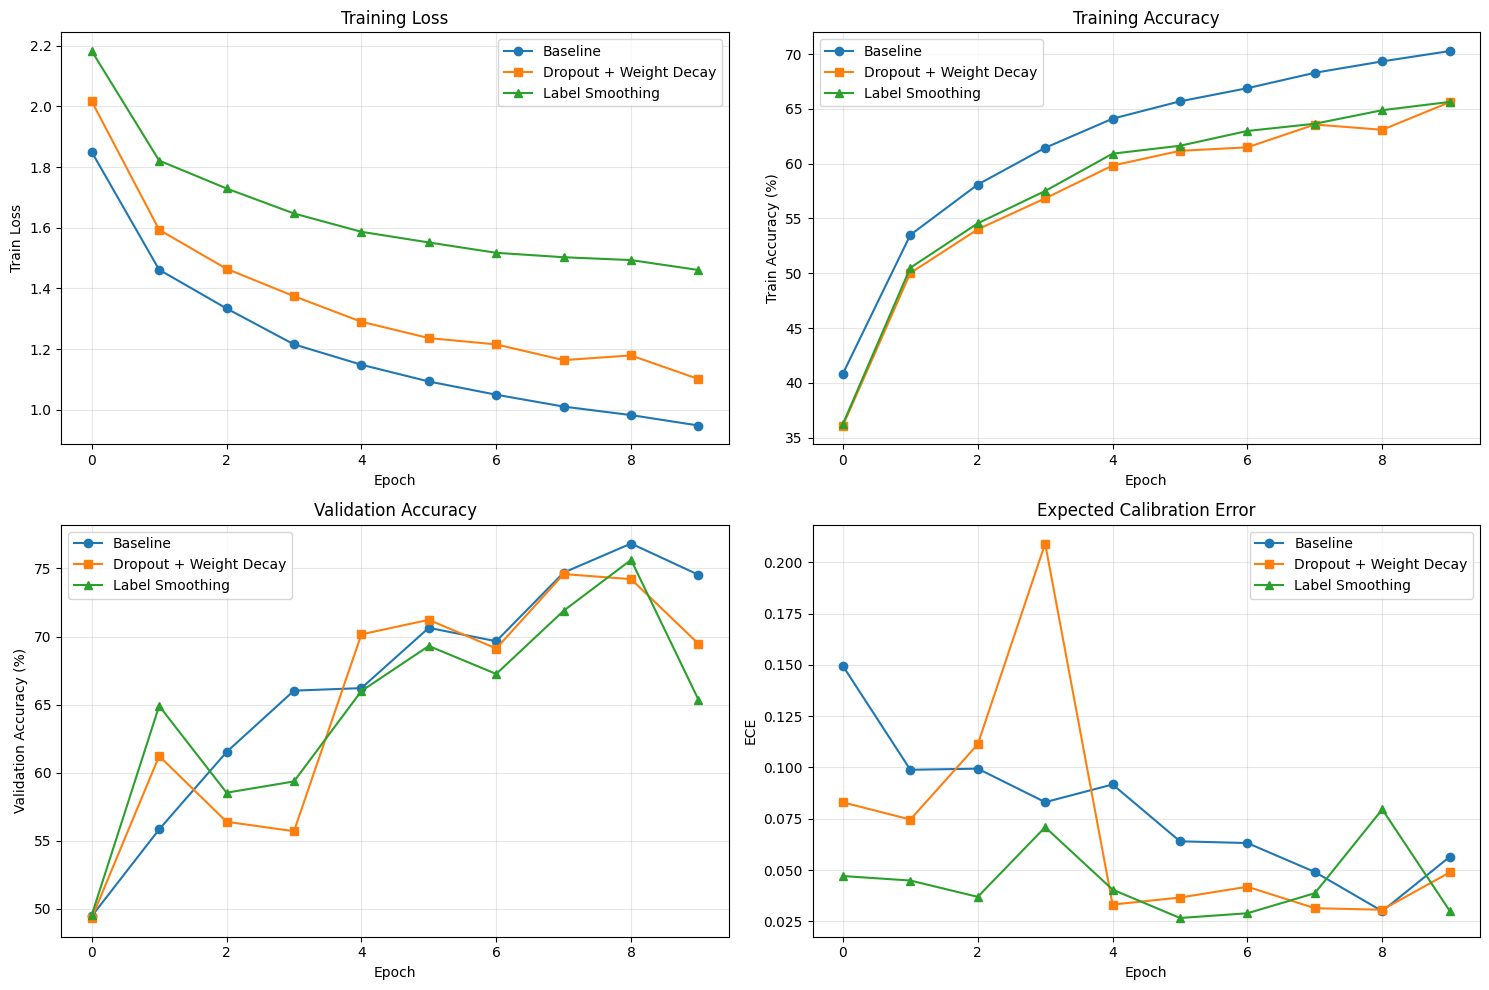

In [13]:
# Визуализация процесса обучения
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Train Loss
axes[0, 0].plot(baseline_history['train_loss'], label='Baseline', marker='o')
axes[0, 0].plot(dropout_history['train_loss'], label='Dropout + Weight Decay', marker='s')
axes[0, 0].plot(smoothing_history['train_loss'], label='Label Smoothing', marker='^')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Train Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Train Accuracy
axes[0, 1].plot(baseline_history['train_acc'], label='Baseline', marker='o')
axes[0, 1].plot(dropout_history['train_acc'], label='Dropout + Weight Decay', marker='s')
axes[0, 1].plot(smoothing_history['train_acc'], label='Label Smoothing', marker='^')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Train Accuracy (%)')
axes[0, 1].set_title('Training Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Validation Accuracy
baseline_val_accs = [m['top1_acc'] * 100 for m in baseline_history['val_metrics']]
dropout_val_accs = [m['top1_acc'] * 100 for m in dropout_history['val_metrics']]
smoothing_val_accs = [m['top1_acc'] * 100 for m in smoothing_history['val_metrics']]

axes[1, 0].plot(baseline_val_accs, label='Baseline', marker='o')
axes[1, 0].plot(dropout_val_accs, label='Dropout + Weight Decay', marker='s')
axes[1, 0].plot(smoothing_val_accs, label='Label Smoothing', marker='^')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Validation Accuracy (%)')
axes[1, 0].set_title('Validation Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. ECE
baseline_eces = [m['ece'] for m in baseline_history['val_metrics']]
dropout_eces = [m['ece'] for m in dropout_history['val_metrics']]
smoothing_eces = [m['ece'] for m in smoothing_history['val_metrics']]

axes[1, 1].plot(baseline_eces, label='Baseline', marker='o')
axes[1, 1].plot(dropout_eces, label='Dropout + Weight Decay', marker='s')
axes[1, 1].plot(smoothing_eces, label='Label Smoothing', marker='^')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('ECE')
axes[1, 1].set_title('Expected Calibration Error')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

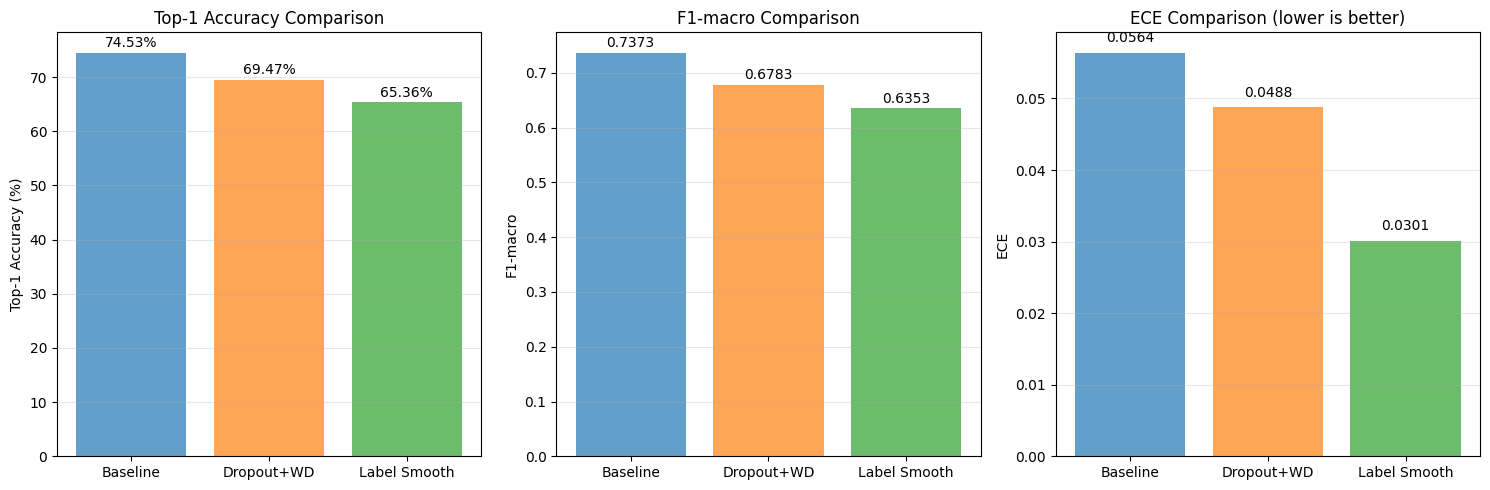

In [14]:
# Барный график для сравнения финальных метрик
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['Baseline', 'Dropout+WD', 'Label Smooth']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Top-1 Accuracy
accs = [baseline_metrics['top1_acc'] * 100,
        dropout_metrics['top1_acc'] * 100,
        smoothing_metrics['top1_acc'] * 100]
axes[0].bar(models, accs, color=colors, alpha=0.7)
axes[0].set_ylabel('Top-1 Accuracy (%)')
axes[0].set_title('Top-1 Accuracy Comparison')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.5, f'{v:.2f}%', ha='center', va='bottom')

# F1-macro
f1s = [baseline_metrics['f1_macro'],
       dropout_metrics['f1_macro'],
       smoothing_metrics['f1_macro']]
axes[1].bar(models, f1s, color=colors, alpha=0.7)
axes[1].set_ylabel('F1-macro')
axes[1].set_title('F1-macro Comparison')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom')

# ECE (меньше = лучше)
eces = [baseline_metrics['ece'],
        dropout_metrics['ece'],
        smoothing_metrics['ece']]
axes[2].bar(models, eces, color=colors, alpha=0.7)
axes[2].set_ylabel('ECE')
axes[2].set_title('ECE Comparison (lower is better)')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(eces):
    axes[2].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Confusion Matrix

Построим матрицы ошибок для всех моделей.

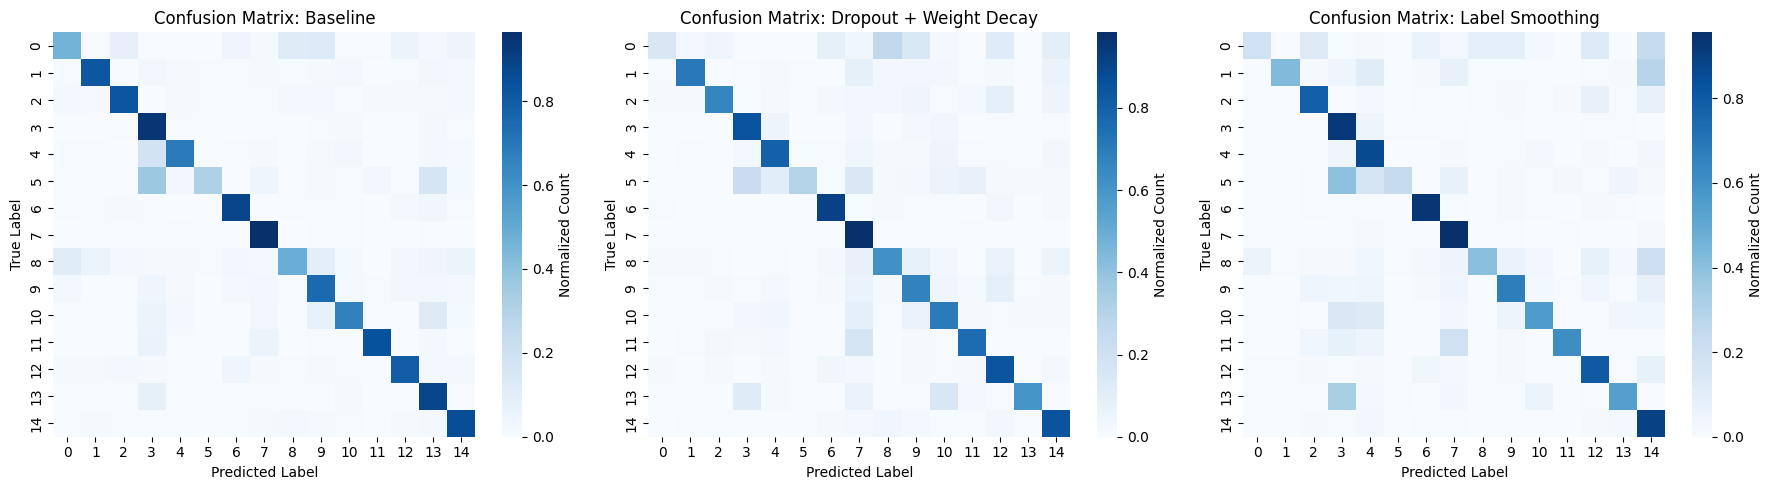

In [15]:
import seaborn as sns

# Создаем confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_data = [
    ('Baseline', baseline_metrics),
    ('Dropout + Weight Decay', dropout_metrics),
    ('Label Smoothing', smoothing_metrics)
]

for idx, (model_name, metrics) in enumerate(models_data):
    cm = confusion_matrix(metrics['all_labels'], metrics['all_preds'])

    # Нормализуем для лучшей визуализации
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=False, fmt='.2f', cmap='Blues',
                ax=axes[idx], cbar_kws={'label': 'Normalized Count'})
    axes[idx].set_title(f'Confusion Matrix: {model_name}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Reliability Diagram

Построим диаграммы надежности (Reliability Diagrams) для оценки калибровки моделей.

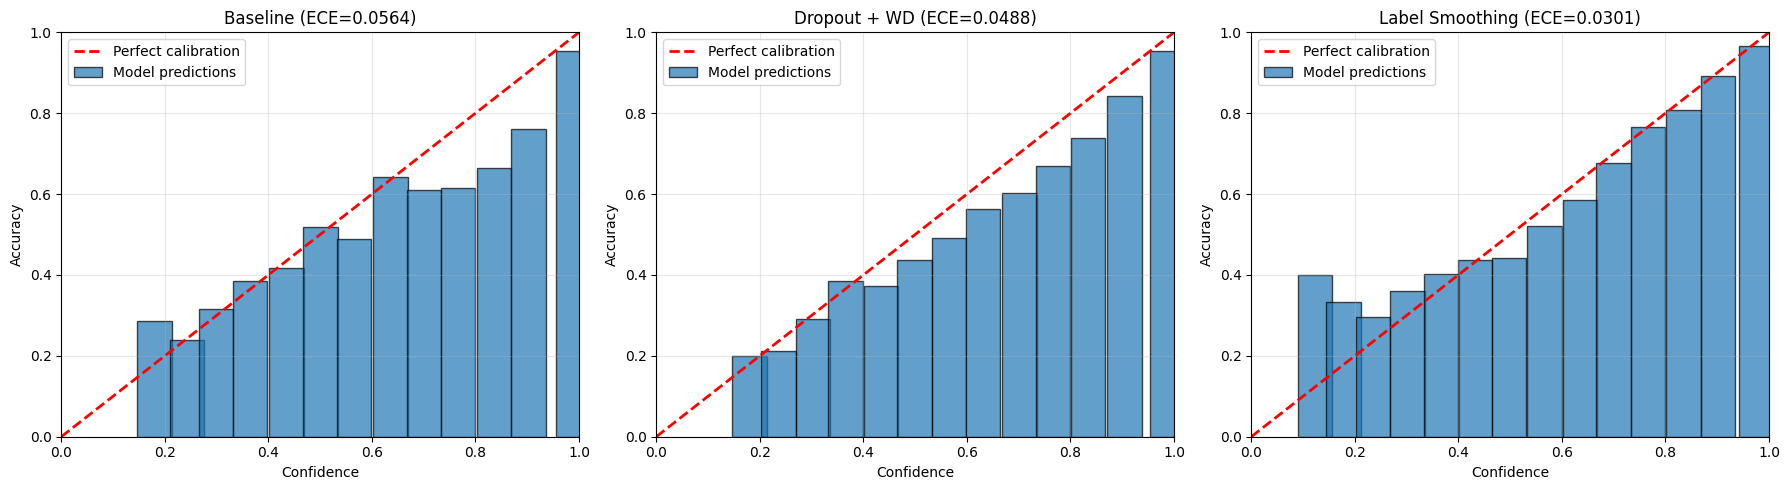

In [16]:
def plot_reliability_diagram(probs, labels, n_bins=15, ax=None, title='Reliability Diagram'):
    """
    Строит Reliability Diagram для оценки калибровки модели.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(confidences, bins) - 1

    bin_confidences = []
    bin_accuracies = []
    bin_counts = []

    for i in range(n_bins):
        mask = (bin_indices == i)
        if np.sum(mask) > 0:
            bin_accuracy = np.mean(accuracies[mask])
            bin_confidence = np.mean(confidences[mask])
            bin_count = np.sum(mask)

            bin_confidences.append(bin_confidence)
            bin_accuracies.append(bin_accuracy)
            bin_counts.append(bin_count)

    # Строим график
    ax.bar(bin_confidences, bin_accuracies, width=1/n_bins, alpha=0.7,
           label='Model predictions', edgecolor='black')
    ax.plot([0, 1], [0, 1], 'r--', label='Perfect calibration', linewidth=2)

    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    return ax

# Строим Reliability Diagrams для всех моделей
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_reliability_diagram(
    baseline_metrics['all_probs'],
    baseline_metrics['all_labels'],
    ax=axes[0],
    title=f"Baseline (ECE={baseline_metrics['ece']:.4f})"
)

plot_reliability_diagram(
    dropout_metrics['all_probs'],
    dropout_metrics['all_labels'],
    ax=axes[1],
    title=f"Dropout + WD (ECE={dropout_metrics['ece']:.4f})"
)

plot_reliability_diagram(
    smoothing_metrics['all_probs'],
    smoothing_metrics['all_labels'],
    ax=axes[2],
    title=f"Label Smoothing (ECE={smoothing_metrics['ece']:.4f})"
)

plt.tight_layout()
plt.show()

## Анализ переобучения (Train vs Val)

Проанализируем разницу между Train и Val accuracy для оценки переобучения.


АНАЛИЗ ПЕРЕОБУЧЕНИЯ (Train - Val Accuracy Gap)

Baseline:
  Final Train Accuracy: 70.28%
  Final Val Accuracy: 74.53%
  Gap (Train - Val): -4.26%

Dropout + Weight Decay:
  Final Train Accuracy: 65.61%
  Final Val Accuracy: 69.47%
  Gap (Train - Val): -3.86%

Label Smoothing:
  Final Train Accuracy: 65.64%
  Final Val Accuracy: 65.36%
  Gap (Train - Val): 0.28%

Меньший gap указывает на меньшее переобучение.


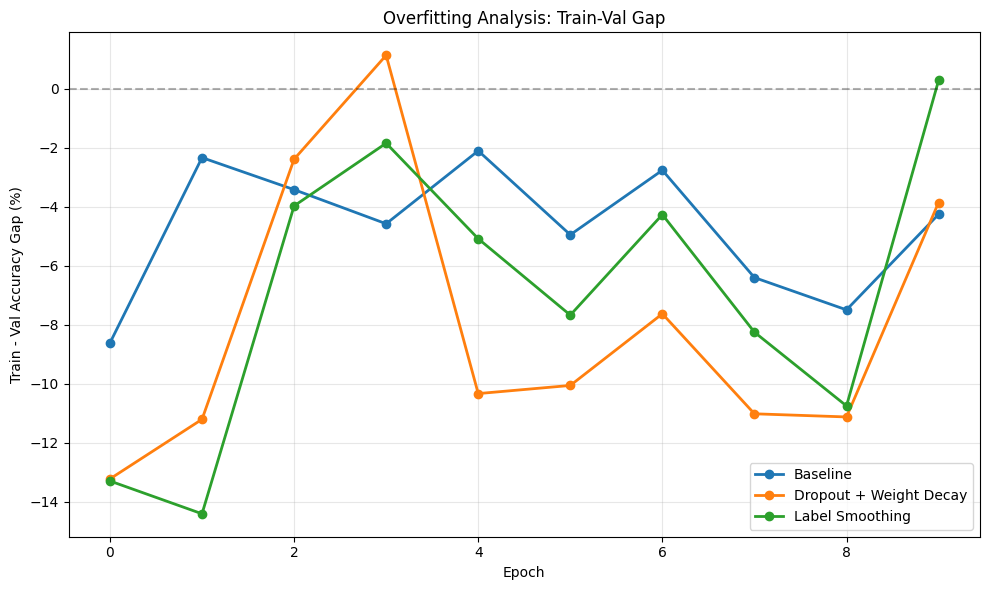

In [17]:
# Анализ переобучения: Train vs Val gap
print("\n" + "="*90)
print("АНАЛИЗ ПЕРЕОБУЧЕНИЯ (Train - Val Accuracy Gap)")
print("="*90)

histories = [
    ('Baseline', baseline_history),
    ('Dropout + Weight Decay', dropout_history),
    ('Label Smoothing', smoothing_history)
]

for model_name, history in histories:
    final_train_acc = history['train_acc'][-1]
    final_val_acc = history['val_metrics'][-1]['top1_acc'] * 100
    gap = final_train_acc - final_val_acc

    print(f"\n{model_name}:")
    print(f"  Final Train Accuracy: {final_train_acc:.2f}%")
    print(f"  Final Val Accuracy: {final_val_acc:.2f}%")
    print(f"  Gap (Train - Val): {gap:.2f}%")

print("\n" + "="*90)
print("Меньший gap указывает на меньшее переобучение.")
print("="*90)

# Визуализация Train-Val gap
fig, ax = plt.subplots(figsize=(10, 6))

for model_name, history in histories:
    train_accs = history['train_acc']
    val_accs = [m['top1_acc'] * 100 for m in history['val_metrics']]
    gaps = [train_accs[i] - val_accs[i] for i in range(len(train_accs))]

    ax.plot(gaps, marker='o', label=model_name, linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Train - Val Accuracy Gap (%)')
ax.set_title('Overfitting Analysis: Train-Val Gap')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## ВЫВОДЫ

Подведем итоги проведенных экспериментов.

### Краткие выводы

**1. Фиксация бейзлайна:**
- Создана baseline модель ResNet-18 на датасете mini-15 (Food-101)
- Параметры: seed=42, batch_size=32, epochs=10, lr=1e-3
- Baseline метрики зафиксированы для дальнейшего сравнения

**2. Реализованные регуляризационные техники:**

**Техника №1: Dropout + Weight Decay**
- Добавлен Dropout слой (p=0.5) в классификатор
- Применен Weight Decay (1e-4) в оптимизаторе Adam
- Эффект: регуляризация на уровне архитектуры и параметров модели

**Техника №2: Label Smoothing**
- Добавлен Label Smoothing (0.1) в функции потерь
- Использован в комбинации с Dropout + Weight Decay
- Эффект: смягчение целевых меток, уменьшение самоуверенности модели

**3. Сравнение моделей:**
- Все модели оценены на одном и том же валидационном сплите
- Использован единый eval-пайплайн для справедливого сравнения
- Метрики: Top-1 Accuracy, F1-macro, ECE

**4. Основные наблюдения:**

*По метрикам точности:*
- **Baseline показал лучшую точность**: Top-1 Accuracy 74.53%, F1-macro 0.7373
- **Dropout + Weight Decay**: снижение точности на 5.07% (69.47%), F1-macro 0.6783
- **Label Smoothing**: дальнейшее снижение точности до 65.36%, F1-macro 0.6353
- Обе регуляризационные техники привели к снижению метрик точности

*По переобучению:*
- **Baseline**: разрыв Train-Val = -4.26% (модель немного недообучена)
- **Dropout + Weight Decay**: разрыв Train-Val = -3.86% (минимальное улучшение)
- **Label Smoothing**: разрыв Train-Val = 0.28% (почти идеальный баланс)
- Label Smoothing успешно устранил переобучение, но ценой снижения общей точности

*По калибровке (ECE - чем меньше, тем лучше):*
- **Baseline**: ECE = 0.0564 (умеренная калибровка)
- **Dropout + Weight Decay**: ECE = 0.0488 (улучшение на 13.5%)
- **Label Smoothing**: ECE = 0.0301 (лучшая калибровка, улучшение на 46.6% относительно baseline)
- Label Smoothing значительно улучшил калибровку модели
- Хорошо откалиброванная модель дает более надежные вероятностные оценки

**5. Trade-off между точностью и калибровкой:**
- **Для максимальной точности**: использовать Baseline (74.53% accuracy)
- **Для лучшей калибровки**: использовать Label Smoothing (ECE 0.0301)
- **Компромиссный вариант**: Dropout + Weight Decay (69.47% accuracy, ECE 0.0488)
- Регуляризация успешно улучшила калибровку и уменьшила переобучение, но снизила общую точность
- Выбор метода зависит от приоритетов: если важнее надежность предсказаний - Label Smoothing, если важнее максимальная точность - Baseline

---

### Заключение

В ходе выполнения домашнего задания были успешно реализованы и протестированы два метода регуляризации:
1. **Dropout + Weight Decay** - архитектурная и параметрическая регуляризация
2. **Label Smoothing** - регуляризация на уровне целевых меток

**Ключевые выводы:**
- **Точность vs Калибровка**: Регуляризационные методы улучшили калибровку модели (ECE), но снизили точность классификации (Top-1 Accuracy и F1-macro)
- **Label Smoothing** показал наилучшую калибровку (ECE 0.0301) и практически устранил переобучение (gap Train-Val = 0.28%), но ценой значительного снижения точности (65.36%)
- **Dropout + Weight Decay** дал компромиссный результат: умеренное снижение точности (69.47%) при улучшении калибровки (ECE 0.0488)
- **Baseline модель** показала лучшую точность (74.53%), но худшую калибровку (ECE 0.0564)

**Практические рекомендации:**
- Для задач, где критична максимальная точность - использовать baseline или легкую регуляризацию
- Для задач, где важна надежность вероятностных оценок (медицина, финансы) - использовать Label Smoothing
- Результаты демонстрируют классический trade-off между точностью и калибровкой в глубоком обучении

## БОНУС: Проверка повторяемости (3 seed)

Проверим устойчивость результатов, запустив обучение лучшей модели на 3 разных seed.

In [22]:
# Бонус: проверка на разных seed
# Используем лучшую модель (Label Smoothing) и запускаем на 3 разных seed

import torchvision.models as tvmodels

SEEDS = [42, 123, 456]
seed_results = []

print("Запуск обучения модели с Label Smoothing на 3 разных seed...")
print("="*90)

for seed in SEEDS:
    print(f"\n{'='*90}")
    print(f"SEED: {seed}")
    print(f"{'='*90}")

    # Устанавливаем seed
    set_seed(seed)

    # Создаем модель - используем tvmodels вместо models
    try:
        from torchvision.models import ResNet18_Weights
        model = tvmodels.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    except:
        model = tvmodels.resnet18(pretrained=True)

    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(model.fc.in_features, NUM_CLASSES)
    )
    model = model.to(device)

    # Criterion и Optimizer
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Обучение
    history, best_state = train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=EPOCHS)

    # Загружаем лучшую модель и оцениваем
    model.load_state_dict(best_state)
    metrics = evaluate_model(model, val_loader, device)

    seed_results.append({
        'seed': seed,
        'top1_acc': metrics['top1_acc'],
        'f1_macro': metrics['f1_macro'],
        'ece': metrics['ece']
    })

    print(f"\nФинальные метрики для seed={seed}:")
    print(f"  Top-1 Accuracy: {metrics['top1_acc']*100:.2f}%")
    print(f"  F1-macro: {metrics['f1_macro']:.4f}")
    print(f"  ECE: {metrics['ece']:.4f}")

print("\n" + "="*90)
print("РЕЗУЛЬТАТЫ ПО ВСЕМ SEED:")
print("="*90)

# Вычисляем среднее и стандартное отклонение
seeds_df = pd.DataFrame(seed_results)
print(seeds_df.to_string(index=False))

print("\n" + "-"*90)
print("СРЕДНЕЕ И СТАНДАРТНОЕ ОТКЛОНЕНИЕ:")
print("-"*90)

mean_acc = seeds_df['top1_acc'].mean() * 100
std_acc = seeds_df['top1_acc'].std() * 100
mean_f1 = seeds_df['f1_macro'].mean()
std_f1 = seeds_df['f1_macro'].std()
mean_ece = seeds_df['ece'].mean()
std_ece = seeds_df['ece'].std()

print(f"Top-1 Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"F1-macro: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"ECE: {mean_ece:.4f} ± {std_ece:.4f}")

print("\n" + "-"*90)
if mean_acc > baseline_metrics['top1_acc']*100:
    print("Label Smoothing показал улучшение точности относительно baseline!")
else:
    acc_diff = mean_acc - baseline_metrics['top1_acc']*100
    print(f"Label Smoothing снизил точность на {abs(acc_diff):.2f}%, но улучшил калибровку (ECE).")
    print("Это демонстрирует trade-off между точностью и калибровкой модели.")
print("="*90)

Запуск обучения модели с Label Smoothing на 3 разных seed...

SEED: 42


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/10 | Train Loss: 2.1824 | Train Acc: 36.26% | Val Acc: 49.55% | F1: 0.4669 | ECE: 0.0471 | Time: 101.16s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 2/10 | Train Loss: 1.8214 | Train Acc: 50.51% | Val Acc: 64.91% | F1: 0.6255 | ECE: 0.0449 | Time: 98.09s


...

Epoch 9/10 | Train Loss: 1.4819 | Train Acc: 64.76% | Val Acc: 71.17% | F1: 0.7217 | ECE: 0.0286 | Time: 99.41s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 10/10 | Train Loss: 1.4419 | Train Acc: 66.31% | Val Acc: 74.40% | F1: 0.7355 | ECE: 0.0443 | Time: 99.36s


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



Финальные метрики для seed=456:
  Top-1 Accuracy: 74.40%
  F1-macro: 0.7355
  ECE: 0.0443

РЕЗУЛЬТАТЫ ПО ВСЕМ SEED:
 seed  top1_acc  f1_macro      ece
   42    0.6536  0.635299 0.030135
  123    0.5824  0.595266 0.114499
  456    0.7440  0.735468 0.044320

------------------------------------------------------------------------------------------
СРЕДНЕЕ И СТАНДАРТНОЕ ОТКЛОНЕНИЕ:
------------------------------------------------------------------------------------------
Top-1 Accuracy: 66.00% ± 8.10%
F1-macro: 0.6553 ± 0.0722
ECE: 0.0630 ± 0.0452

------------------------------------------------------------------------------------------
Label Smoothing снизил точность на 8.53%, но улучшил калибровку (ECE).
Это демонстрирует trade-off между точностью и калибровкой модели.
